In [1]:
import torch
import os

In [2]:
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [3]:
model_path = '../trained_model/model5/train/my_model.pth'

In [4]:
model = torch.load(model_path)

In [5]:
parameters = {}
for name, param in model.named_parameters():
    parameters[name] = param.detach().numpy()

In [6]:
u1 = parameters['U_c1'].T
u2 = parameters['U_f1']
u3 = parameters['U_i1']
u4 = parameters['U_o1']

In [7]:
y_l = list(range(8)) * 64
x_l = []
for i in range(64):
    i_l = [i] * 8
    x_l.append(i_l)

In [8]:
lis = []
for i in range(8):
    lii = []
    for j in range(64):
        po = (j, u1[j, i])
        lii.append(po)
    lis.append(lii)

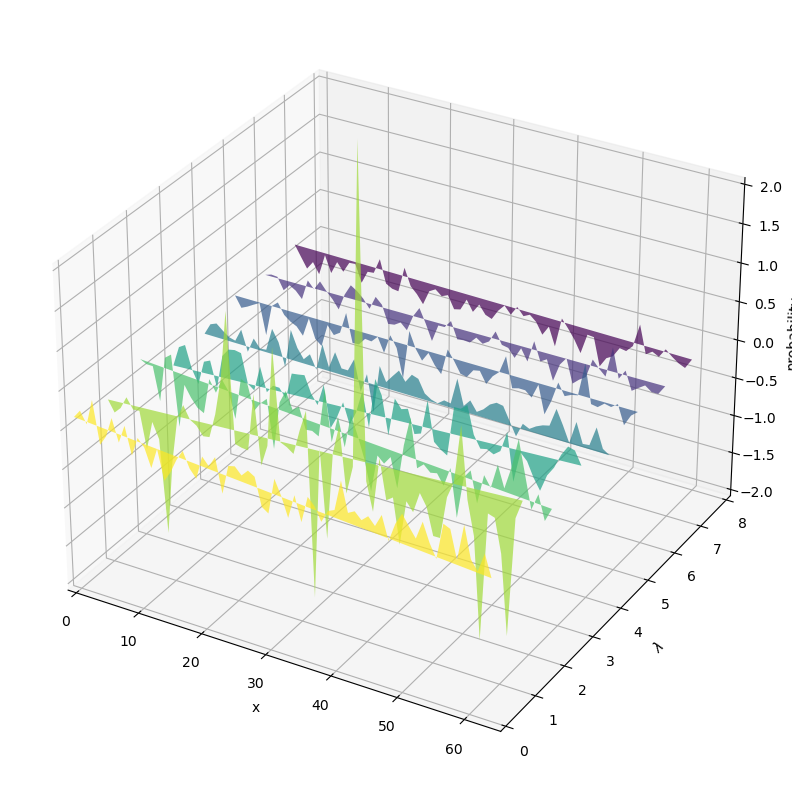

In [9]:
import math

import matplotlib.pyplot as plt
import numpy as np

from matplotlib.collections import PolyCollection


ax = plt.figure(figsize=(20, 10)).add_subplot(projection='3d')

x = np.linspace(0., 63., 64)
lambdas = range(0, 8)

facecolors = plt.colormaps['viridis_r'](np.linspace(0, 1, len(lis)))

poly = PolyCollection(lis, facecolors=facecolors, alpha=.7)
ax.add_collection3d(poly, zs=lambdas, zdir='y')

ax.set(xlim=(0, 64), ylim=(0, 8), zlim=(-2, 2),
       xlabel='x', ylabel=r'$\lambda$', zlabel='probability')

plt.show()

In [10]:
y1 = u1.reshape(-1)
x = np.linspace(0, len(y1)-1, len(y1))

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def scatter_hist(x, y, ax, ax_histy):
    # no labels
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot:
    ax.scatter(x, y)

    # now determine nice limits by hand:
    binwidth = 0.25
    ymax = np.max(np.abs(y))
    lim = (int(ymax/binwidth) + 1) * binwidth

    bins = np.arange(-lim, lim + binwidth, binwidth)
    ax_histy.hist(y, bins=bins, orientation='horizontal')

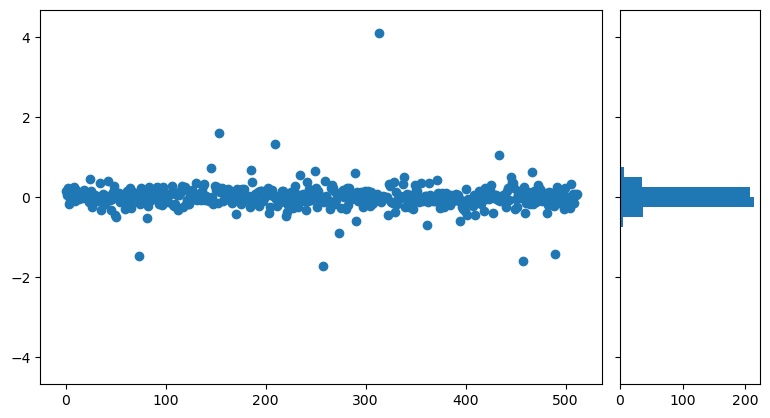

In [13]:
fig = plt.figure(figsize=(9, 6))

gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
#创建子图
ax = fig.add_subplot(gs[1, 0])
#创建子图，共享y轴
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

scatter_hist(x, y1, ax, ax_histy)